# 03 传统特征、分类器与完整分组对比

对应研究架构中的传统分支：PCA/原始光谱 → LBP/Gabor 空间特征 → SVM/XGBoost。每个方法使用独立代码框，并在同一个 seed=1442 固定划分上输出 OA、AA、Kappa、混淆矩阵、逐类准确率与分类图。


In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import yaml
from IPython.display import Image, display

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(path for path in (cwd, *cwd.parents) if (path / "src").is_dir())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
SEED = 1442
print("PROJECT_ROOT =", PROJECT_ROOT)
print("frozen random seed =", SEED)


PROJECT_ROOT = G:\高光谱智能图像解译\hsi_project
frozen random seed = 1442


## 0. 配置与公共特征缓存


In [2]:
from src.coursework.stage3 import prepare_traditional_context, run_traditional_method, save_method_comparison

RUN_METHODS = False  # True 时逐组重新训练；默认加载本次已完成结果
CONFIG_PATH = PROJECT_ROOT / "coursework/configs/stage3_traditional/pavia_traditional.yaml"
OUTPUT_DIR = PROJECT_ROOT / "coursework/outputs/stage3/pavia_traditional"
values = yaml.safe_load(CONFIG_PATH.read_text(encoding="utf-8"))
assert values["experiment"]["seed"] == 1442
context = prepare_traditional_context(PROJECT_ROOT, CONFIG_PATH) if RUN_METHODS else None
pd.DataFrame([{"method": key, **value} for key, value in values["methods"].items()])


,method,display_name,features,classifier
0,PCA15_SVM,PCA15 + SVM,spectral,svm
1,PCA15_XGBoost,PCA15 + XGBoost,spectral,xgboost
2,PCA15_LBP_SVM,PCA15 + LBP + SVM,spectral_lbp,svm
3,PCA15_Gabor_SVM,PCA15 + Gabor + SVM,spectral_gabor,svm
4,PCA15_LBP_Gabor_SVM,PCA15 + LBP + Gabor + SVM,spectral_lbp_gabor,svm
5,PCA15_LBP_Gabor_XGBoost,PCA15 + LBP + Gabor + XGBoost,spectral_lbp_gabor,xgboost


## 1. 每格一种传统方法


### 1.1 `PCA15_SVM`


In [3]:
METHOD_KEY = "PCA15_SVM"
if RUN_METHODS:
    summary = run_traditional_method(context, METHOD_KEY, OUTPUT_DIR)
else:
    summary = json.loads((OUTPUT_DIR / METHOD_KEY / "summary.json").read_text(encoding="utf-8"))
pd.Series(summary)


method                                                                        PCA15_SVM
display_name                                                                PCA15 + SVM
features                                                                       spectral
classifier                                                                          svm
seed                                                                               1442
feature_dimension                                                                    15
validation_oa                                                                  0.941956
test_oa                                                                        0.937016
test_aa                                                                        0.913993
test_kappa                                                                     0.916289
test_errors                                                                        1886
feature_extraction_seconds      

### 1.2 `PCA15_XGBoost`


In [4]:
METHOD_KEY = "PCA15_XGBoost"
if RUN_METHODS:
    summary = run_traditional_method(context, METHOD_KEY, OUTPUT_DIR)
else:
    summary = json.loads((OUTPUT_DIR / METHOD_KEY / "summary.json").read_text(encoding="utf-8"))
pd.Series(summary)


method                                                                    PCA15_XGBoost
display_name                                                            PCA15 + XGBoost
features                                                                       spectral
classifier                                                                      xgboost
seed                                                                               1442
feature_dimension                                                                    15
validation_oa                                                                  0.934944
test_oa                                                                        0.929201
test_aa                                                                        0.900874
test_kappa                                                                     0.905551
test_errors                                                                        2120
feature_extraction_seconds      

### 1.3 `PCA15_LBP_SVM`


In [5]:
METHOD_KEY = "PCA15_LBP_SVM"
if RUN_METHODS:
    summary = run_traditional_method(context, METHOD_KEY, OUTPUT_DIR)
else:
    summary = json.loads((OUTPUT_DIR / METHOD_KEY / "summary.json").read_text(encoding="utf-8"))
pd.Series(summary)


method                                                                    PCA15_LBP_SVM
display_name                                                          PCA15 + LBP + SVM
features                                                                   spectral_lbp
classifier                                                                          svm
seed                                                                               1442
feature_dimension                                                                    63
validation_oa                                                                  0.994936
test_oa                                                                        0.995124
test_aa                                                                        0.993337
test_kappa                                                                     0.993531
test_errors                                                                         146
feature_extraction_seconds      

### 1.4 `PCA15_Gabor_SVM`


In [6]:
METHOD_KEY = "PCA15_Gabor_SVM"
if RUN_METHODS:
    summary = run_traditional_method(context, METHOD_KEY, OUTPUT_DIR)
else:
    summary = json.loads((OUTPUT_DIR / METHOD_KEY / "summary.json").read_text(encoding="utf-8"))
pd.Series(summary)


method                                                                  PCA15_Gabor_SVM
display_name                                                        PCA15 + Gabor + SVM
features                                                                 spectral_gabor
classifier                                                                          svm
seed                                                                               1442
feature_dimension                                                                    63
validation_oa                                                                  0.996494
test_oa                                                                        0.995692
test_aa                                                                        0.995332
test_kappa                                                                     0.994291
test_errors                                                                         129
feature_extraction_seconds      

### 1.5 `PCA15_LBP_Gabor_SVM`


In [7]:
METHOD_KEY = "PCA15_LBP_Gabor_SVM"
if RUN_METHODS:
    summary = run_traditional_method(context, METHOD_KEY, OUTPUT_DIR)
else:
    summary = json.loads((OUTPUT_DIR / METHOD_KEY / "summary.json").read_text(encoding="utf-8"))
pd.Series(summary)


method                                                              PCA15_LBP_Gabor_SVM
display_name                                                  PCA15 + LBP + Gabor + SVM
features                                                             spectral_lbp_gabor
classifier                                                                          svm
seed                                                                               1442
feature_dimension                                                                   111
validation_oa                                                                   0.99961
test_oa                                                                        0.999365
test_aa                                                                        0.999212
test_kappa                                                                     0.999159
test_errors                                                                          19
feature_extraction_seconds      

### 1.6 `PCA15_LBP_Gabor_XGBoost`


In [8]:
METHOD_KEY = "PCA15_LBP_Gabor_XGBoost"
if RUN_METHODS:
    summary = run_traditional_method(context, METHOD_KEY, OUTPUT_DIR)
else:
    summary = json.loads((OUTPUT_DIR / METHOD_KEY / "summary.json").read_text(encoding="utf-8"))
pd.Series(summary)


method                                                          PCA15_LBP_Gabor_XGBoost
display_name                                              PCA15 + LBP + Gabor + XGBoost
features                                                             spectral_lbp_gabor
classifier                                                                      xgboost
seed                                                                               1442
feature_dimension                                                                   111
validation_oa                                                                  0.990261
test_oa                                                                        0.992052
test_aa                                                                        0.987912
test_kappa                                                                     0.989464
test_errors                                                                         238
feature_extraction_seconds      

## 2. 传统方法总表与分类图


,display_name,feature_dimension,validation_oa,test_oa,test_aa,test_kappa,training_seconds,test_inference_seconds,test_throughput_samples_per_second
0,PCA15 + SVM,15,0.941956,0.937016,0.913993,0.916289,19.015258,34.442397,869.393614
1,PCA15 + XGBoost,15,0.934944,0.929201,0.900874,0.905551,15.266166,0.388522,77071.489314
2,PCA15 + LBP + SVM,63,0.994936,0.995124,0.993337,0.993531,38.222043,63.271653,473.260911
3,PCA15 + Gabor + SVM,63,0.996494,0.995692,0.995332,0.994291,22.976187,34.387596,870.779100
4,PCA15 + LBP + Gabor + SVM,111,0.999610,0.999365,0.999212,0.999159,33.323158,55.740161,537.206919
5,PCA15 + LBP + Gabor + XGBoost,111,0.990261,0.992052,0.987912,0.989464,28.783924,0.417467,71727.876738


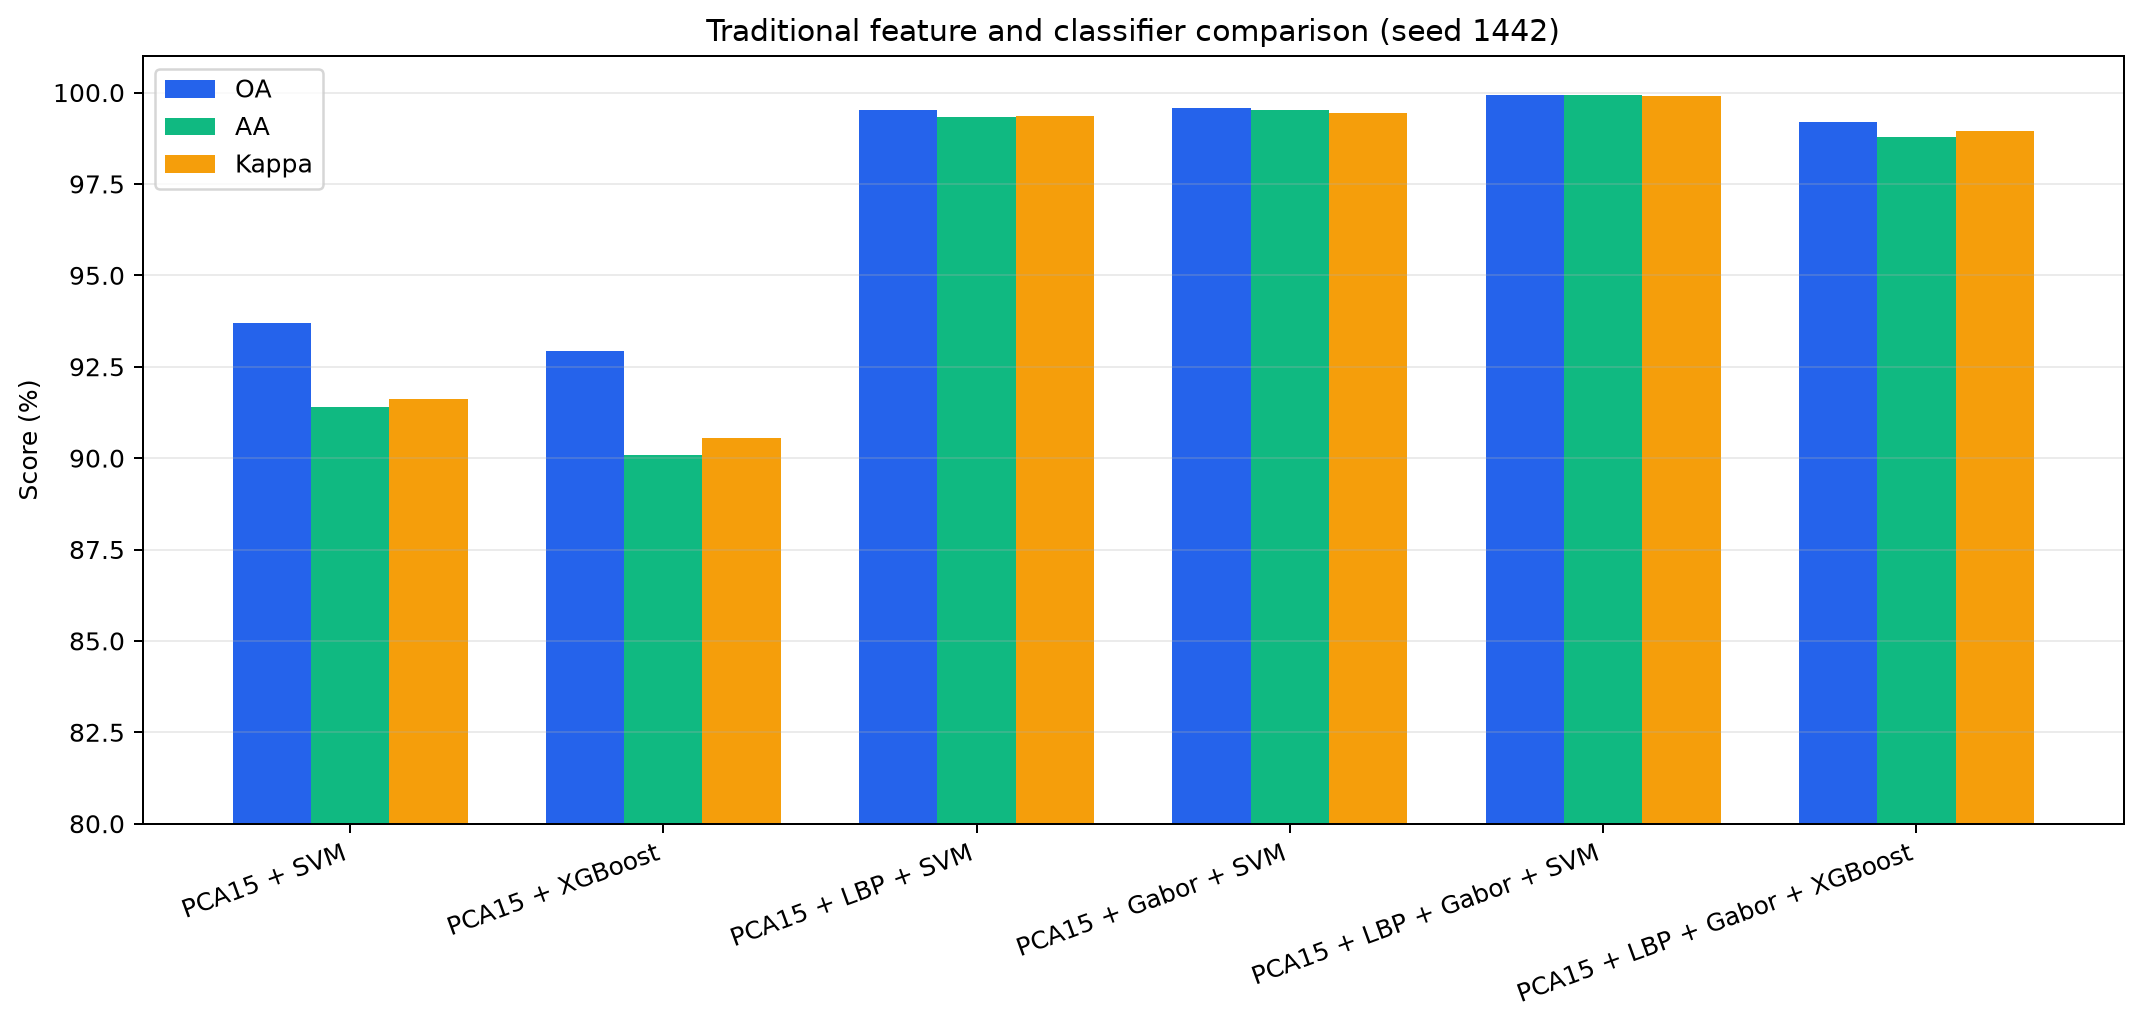

PCA15_SVM


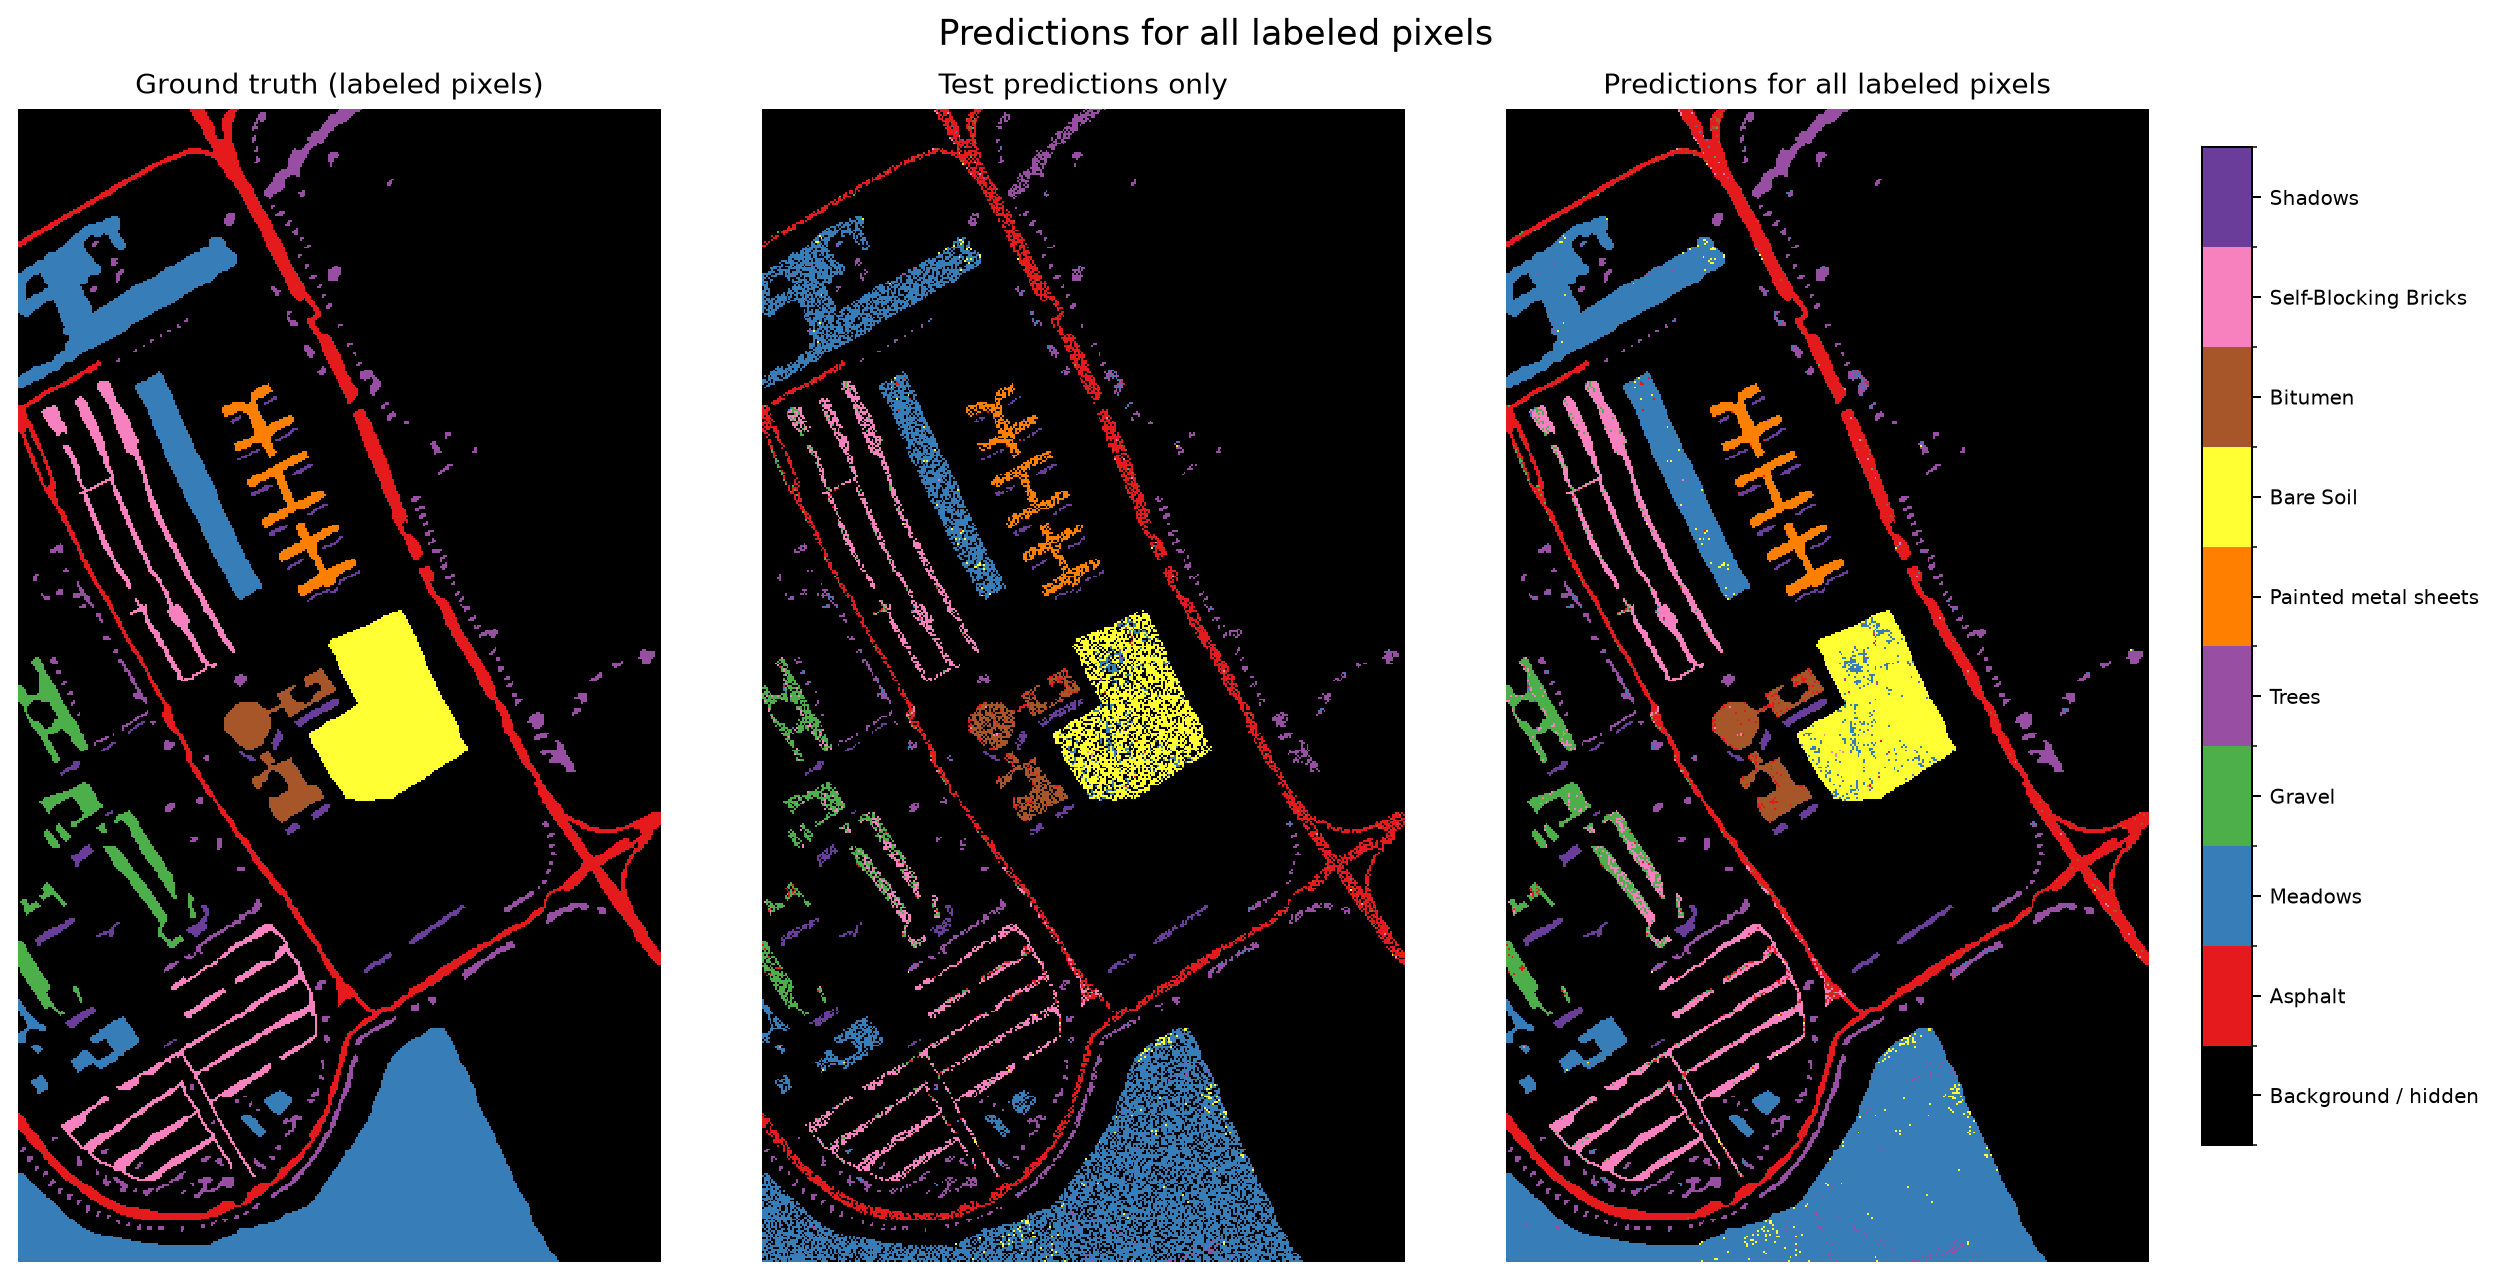

PCA15_LBP_Gabor_SVM


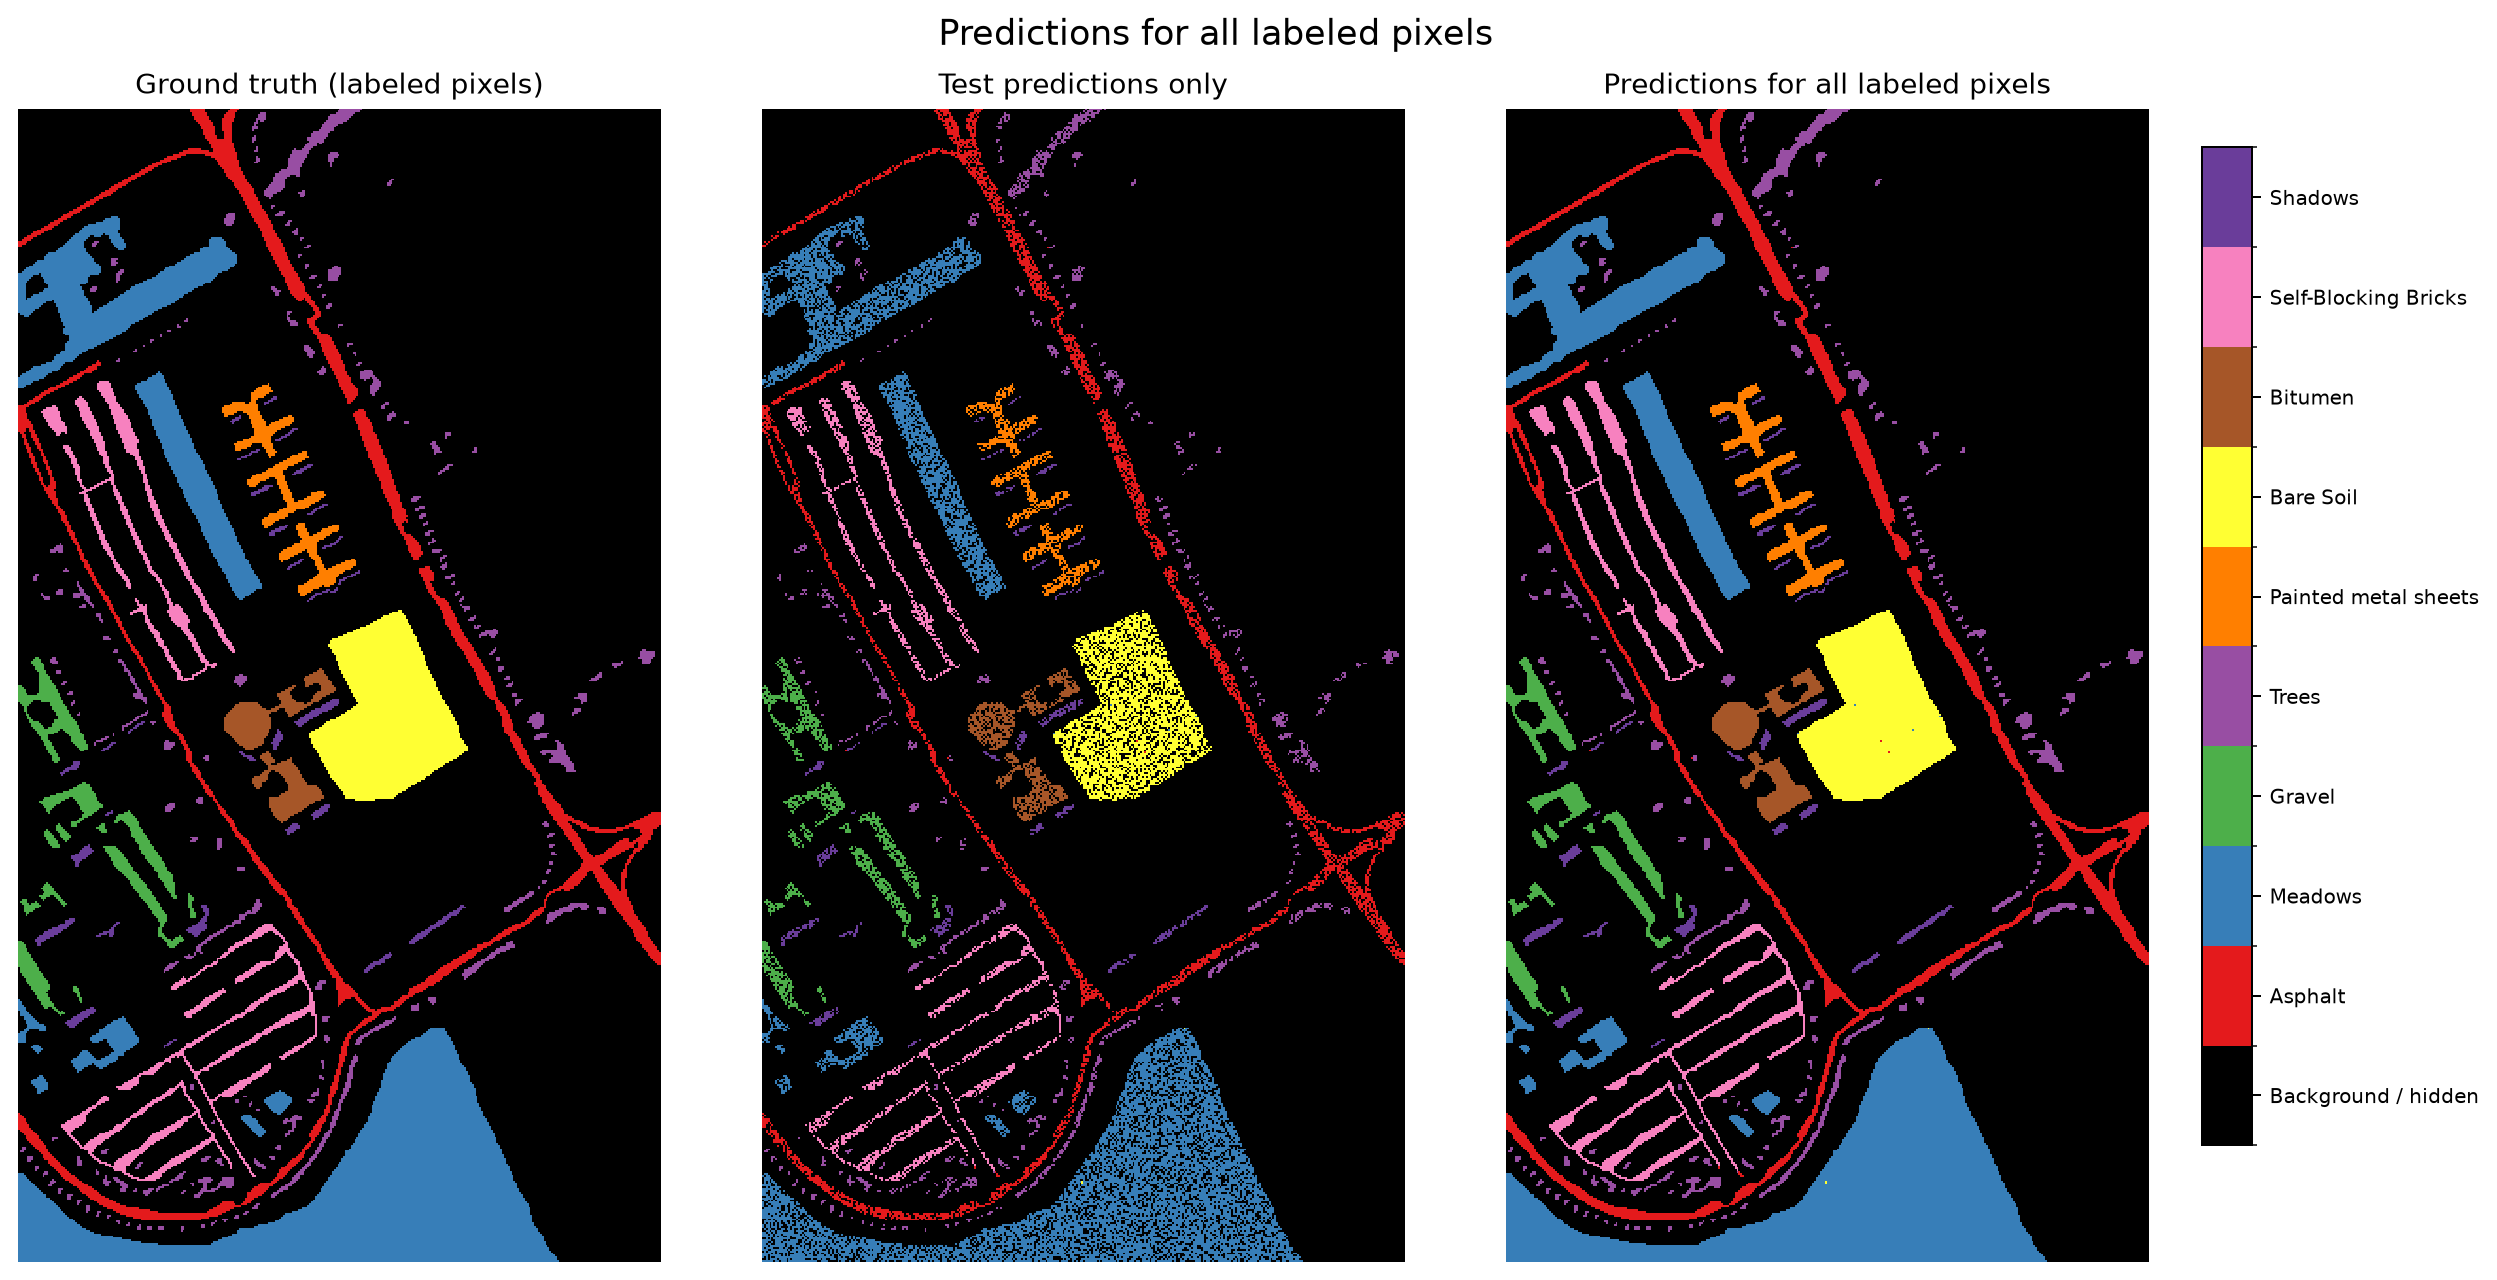

PCA15_LBP_Gabor_XGBoost


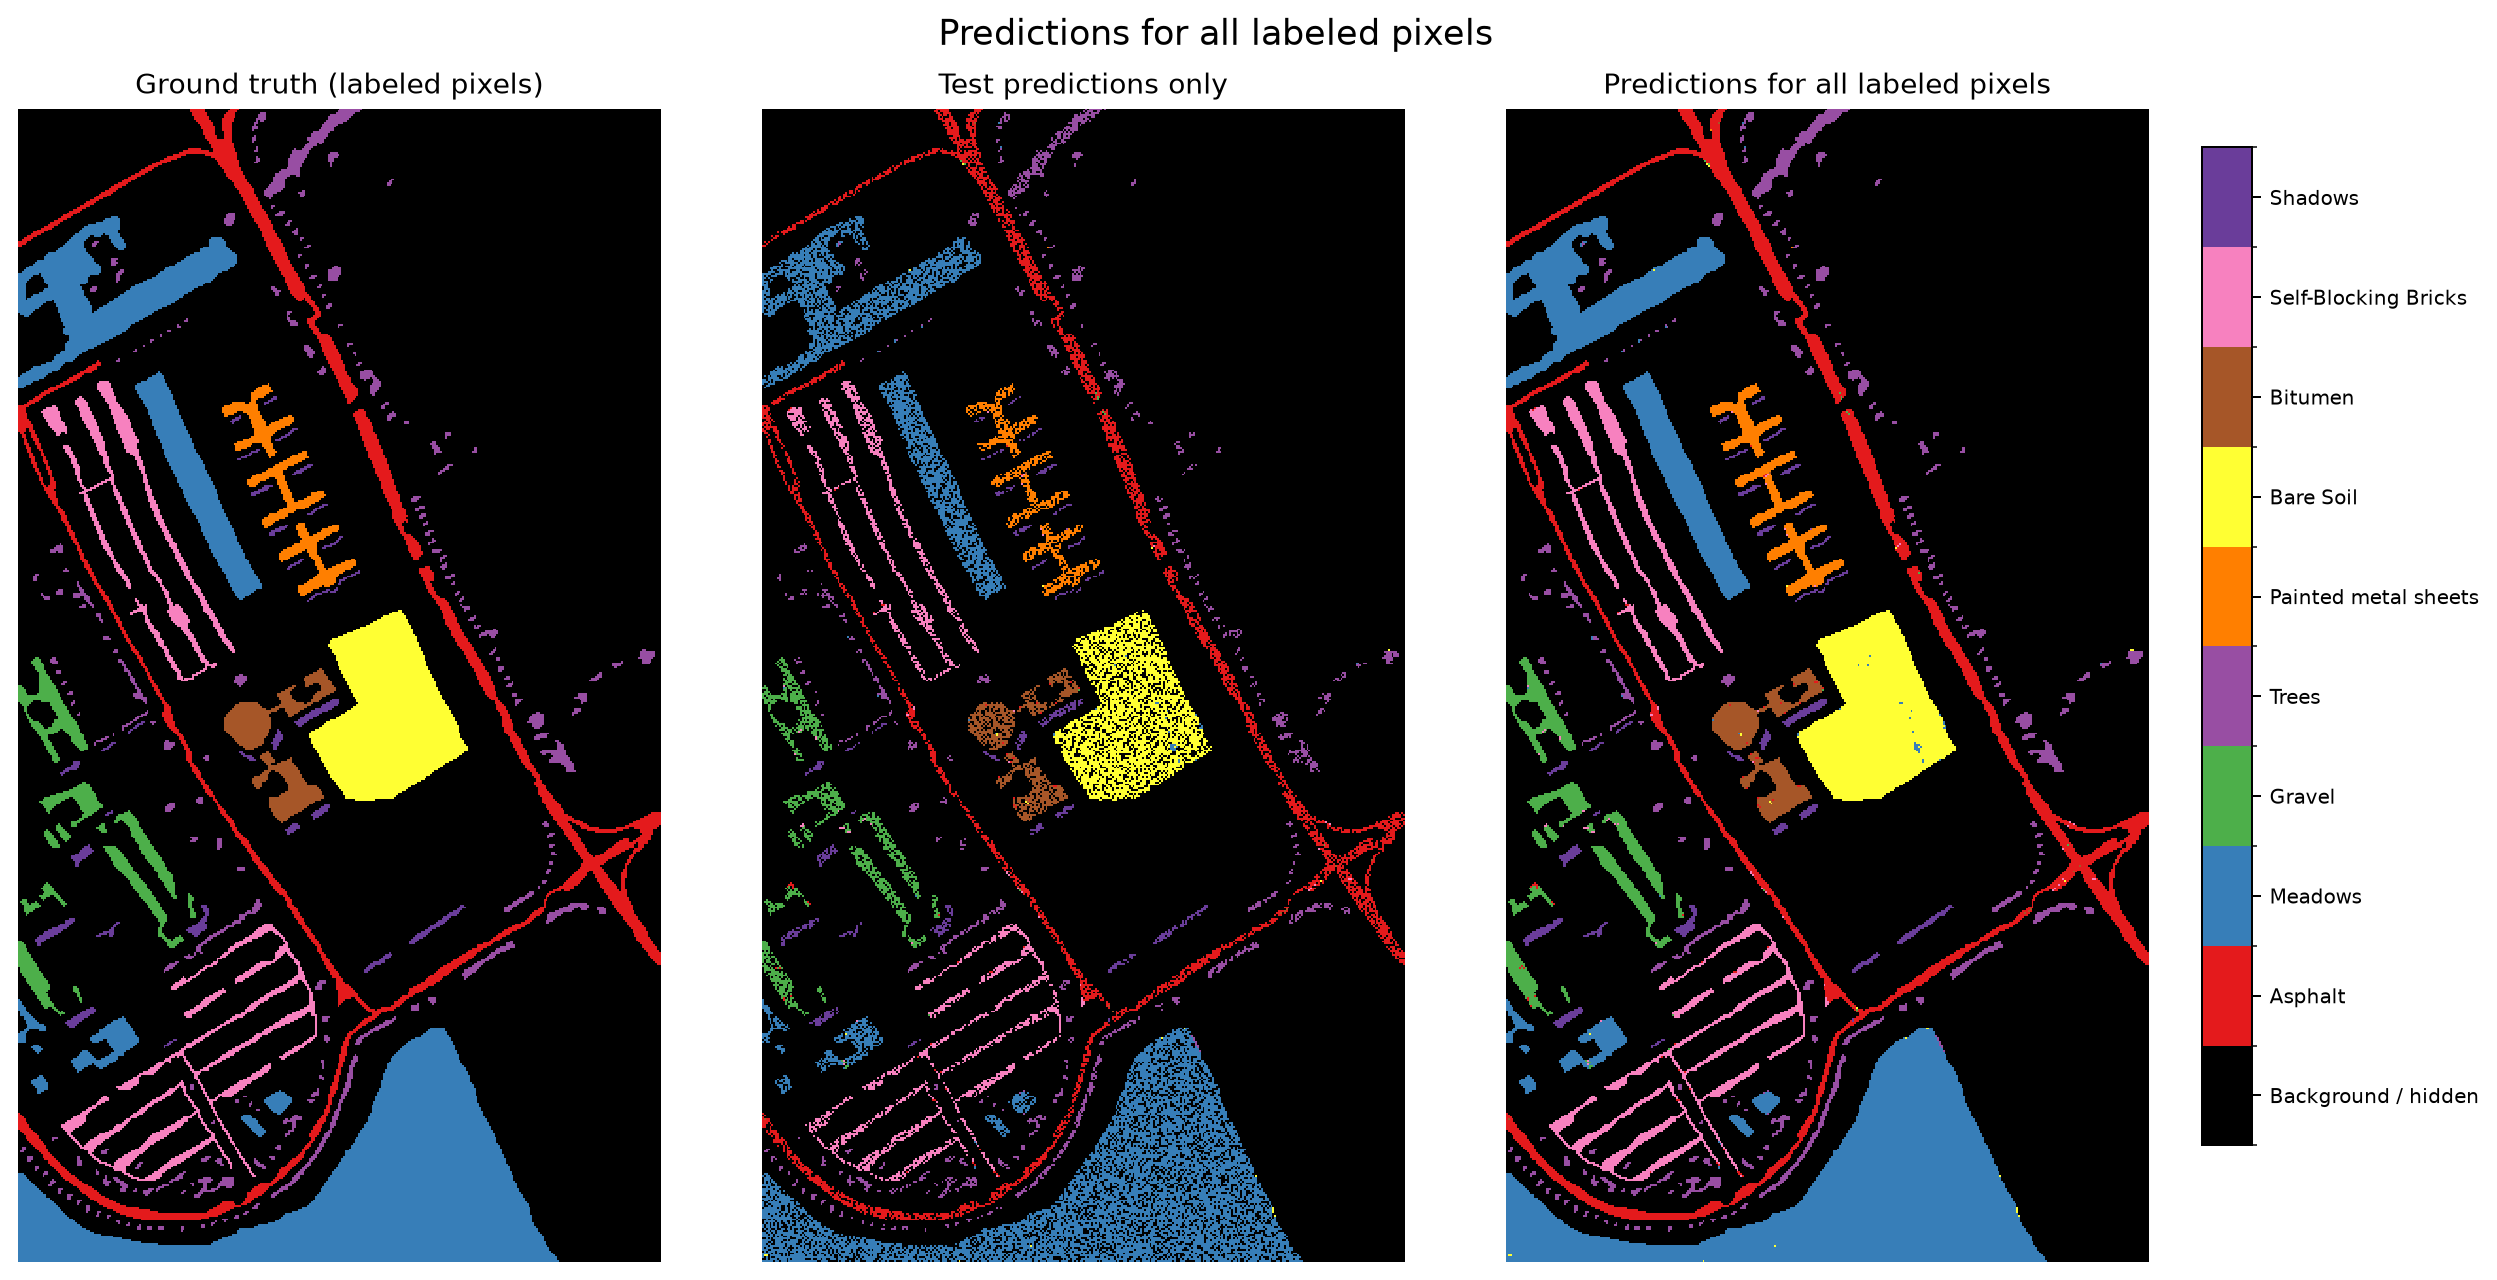

In [9]:
traditional = pd.read_csv(OUTPUT_DIR / "traditional_method_comparison.csv")
display(traditional[["display_name", "feature_dimension", "validation_oa", "test_oa", "test_aa", "test_kappa", "training_seconds", "test_inference_seconds", "test_throughput_samples_per_second"]])
display(Image(filename=str(OUTPUT_DIR / "traditional_method_comparison.png"), width=1050))
for method in ("PCA15_SVM", "PCA15_LBP_Gabor_SVM", "PCA15_LBP_Gabor_XGBoost"):
    print(method)
    display(Image(filename=str(OUTPUT_DIR / method / "classification_maps.png"), width=1050))


## 3. 预处理严格控制变量：同一 RBF-SVM


,route,output_bands,validation_oa,test_oa,test_aa,test_kappa,training_seconds,all_labeled_inference_seconds
0,raw_all_bands,103,0.947409,0.940556,0.918837,0.920732,12.883339,61.752362
1,pca15,15,0.941956,0.937016,0.913993,0.916289,24.096644,61.233954
2,lda8,8,0.914297,0.913438,0.888494,0.884856,11.925652,10.544992
3,uniform15,15,0.907285,0.903620,0.874884,0.870633,1.316833,8.720981
4,fisher15,15,0.696922,0.705884,0.562779,0.583684,3.644363,16.965923


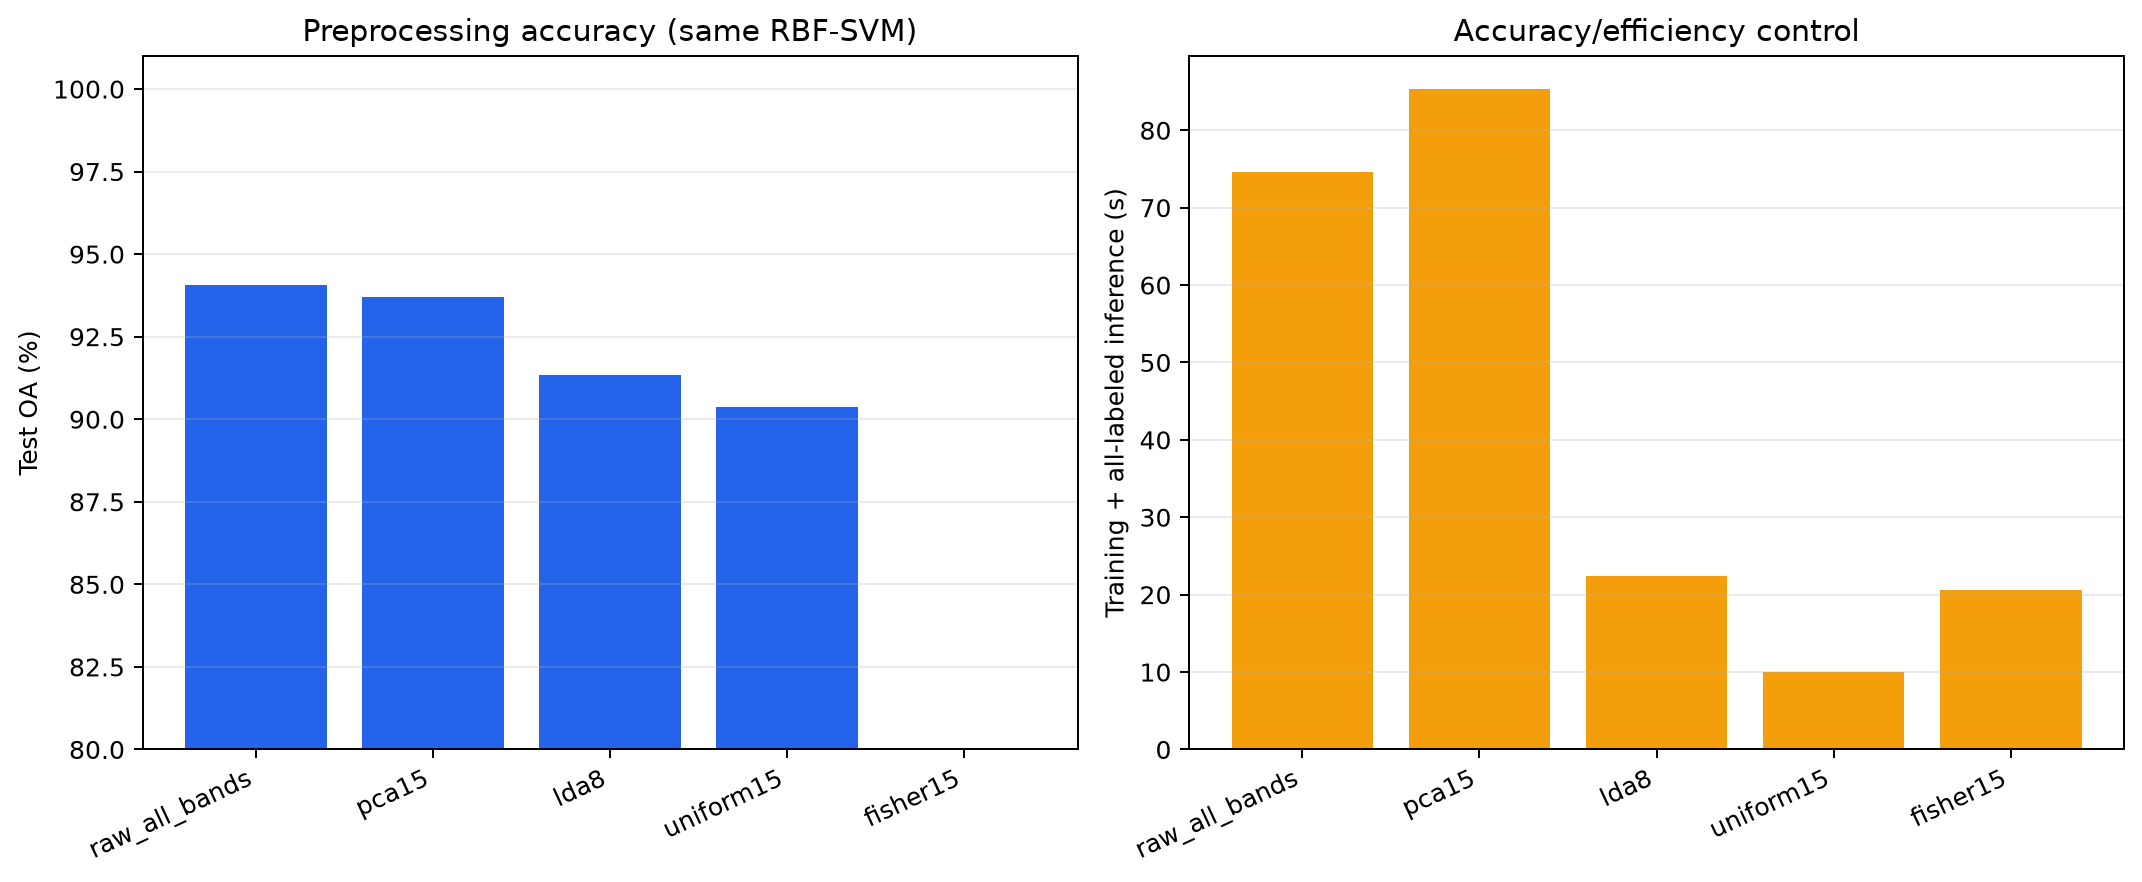

In [10]:
PREPROCESSING_DIR = PROJECT_ROOT / "coursework/outputs/comparisons/preprocessing_svm"
preprocessing = pd.read_csv(PREPROCESSING_DIR / "preprocessing_svm_comparison.csv")
display(preprocessing[["route", "output_bands", "validation_oa", "test_oa", "test_aa", "test_kappa", "training_seconds", "all_labeled_inference_seconds"]])
display(Image(filename=str(PREPROCESSING_DIR / "preprocessing_svm_comparison.png"), width=950))


## 4. 与 HybridSN 的统一比较


,method,family,oa,aa,kappa,training_seconds,test_inference_seconds,model_size_bytes
0,PCA15 + SVM,traditional,0.937016,0.913993,0.916289,19.015258,34.442397,345638
1,PCA15 + XGBoost,traditional,0.929201,0.900874,0.905551,15.266166,0.388522,1365070
2,PCA15 + LBP + SVM,traditional,0.995124,0.993337,0.993531,38.222043,63.271653,951775
3,PCA15 + Gabor + SVM,traditional,0.995692,0.995332,0.994291,22.976187,34.387596,819846
4,PCA15 + LBP + Gabor + SVM,traditional,0.999365,0.999212,0.999159,33.323158,55.740161,1507638
5,PCA15 + LBP + Gabor + XGBoost,traditional,0.992052,0.987912,0.989464,28.783924,0.417467,1127186
6,HybridSN + Softmax,deep learning,0.999065,0.998353,0.998761,110.238234,6.938057,19384633
7,HybridSN + Sigmoid,deep learning,0.999699,0.999205,0.999602,157.211688,7.062666,19384633


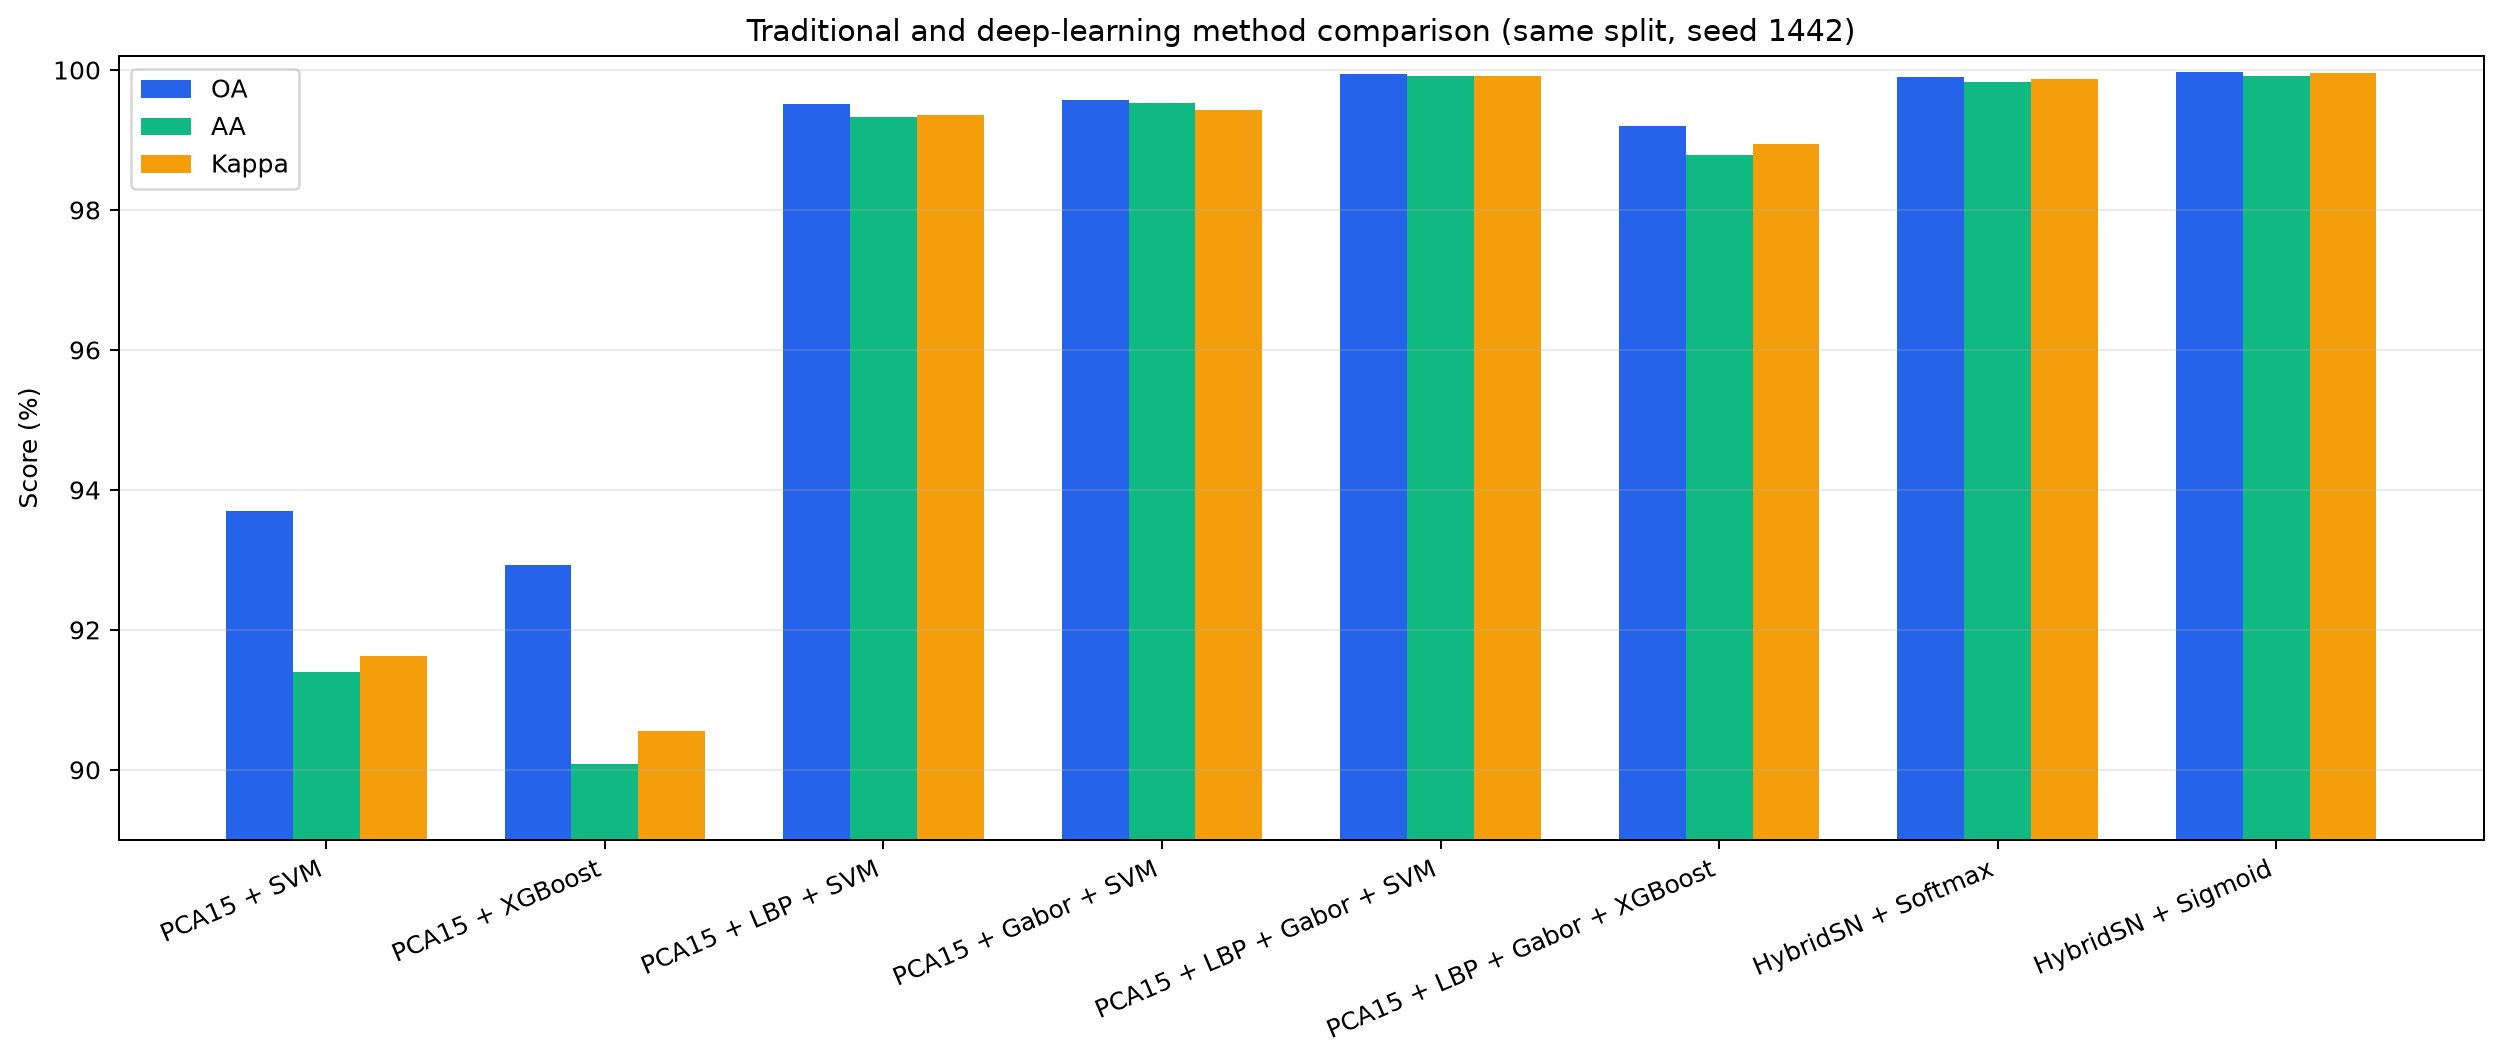

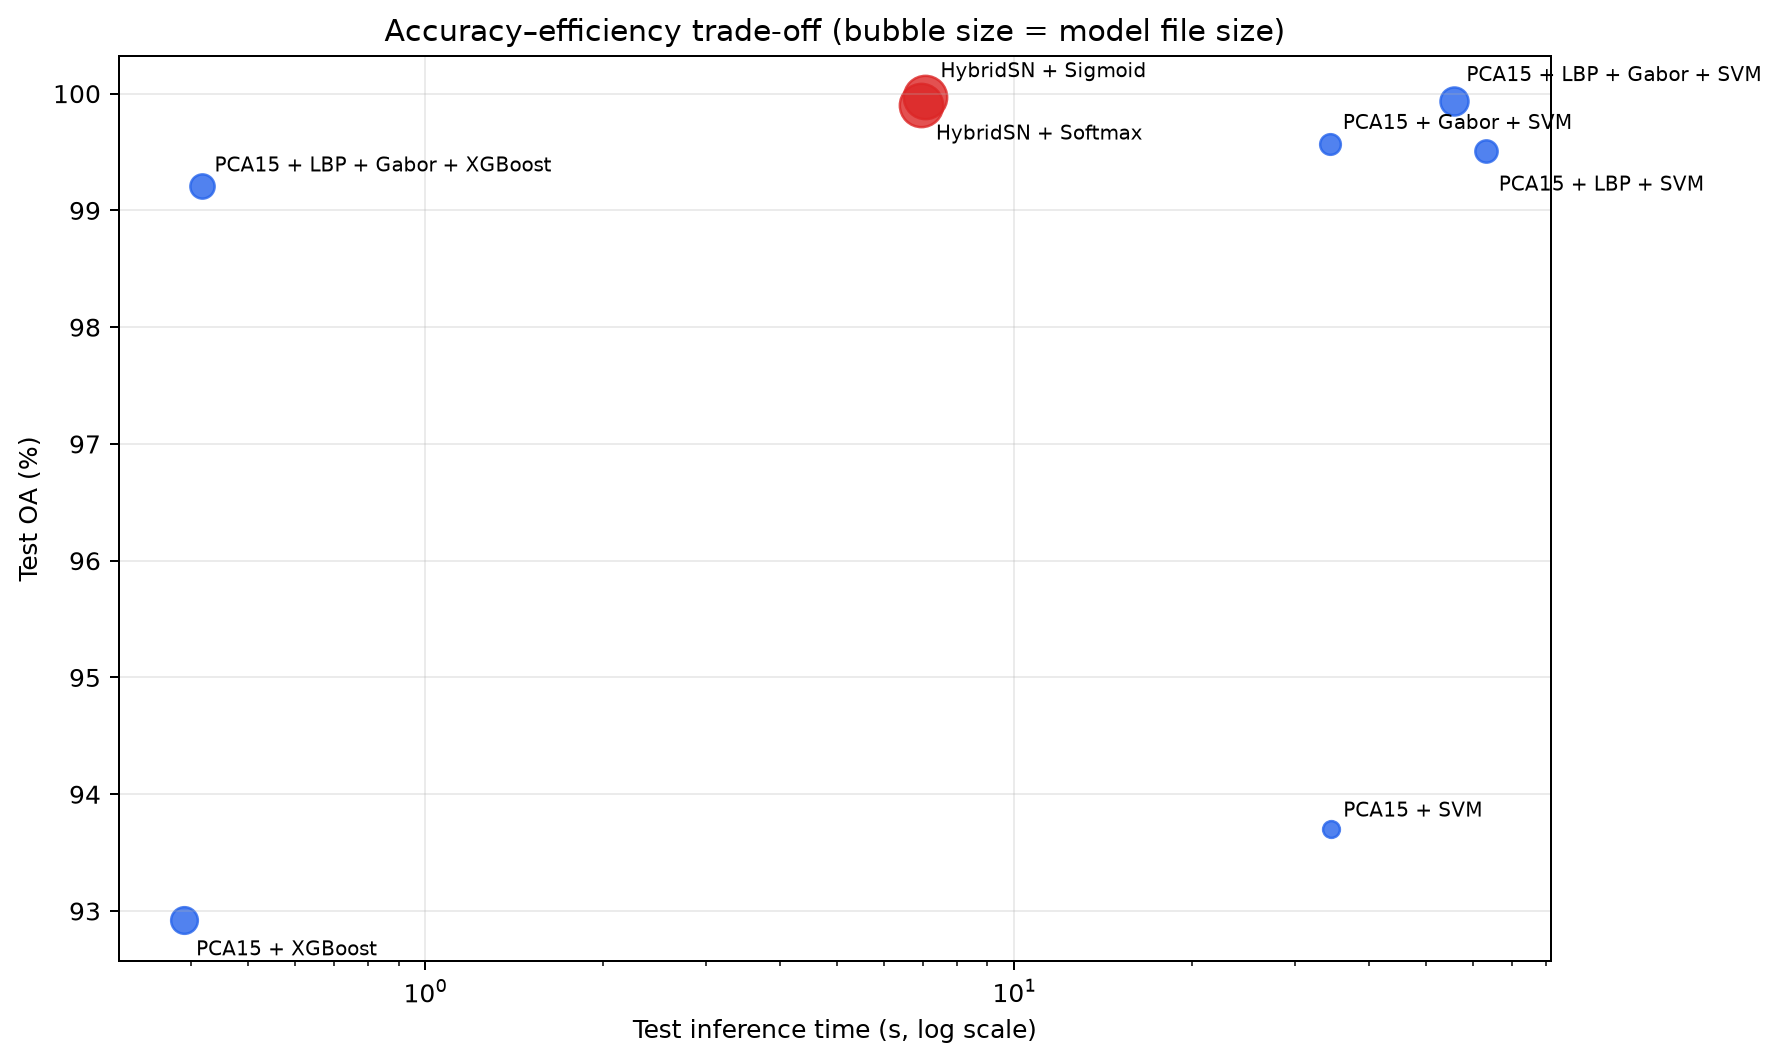

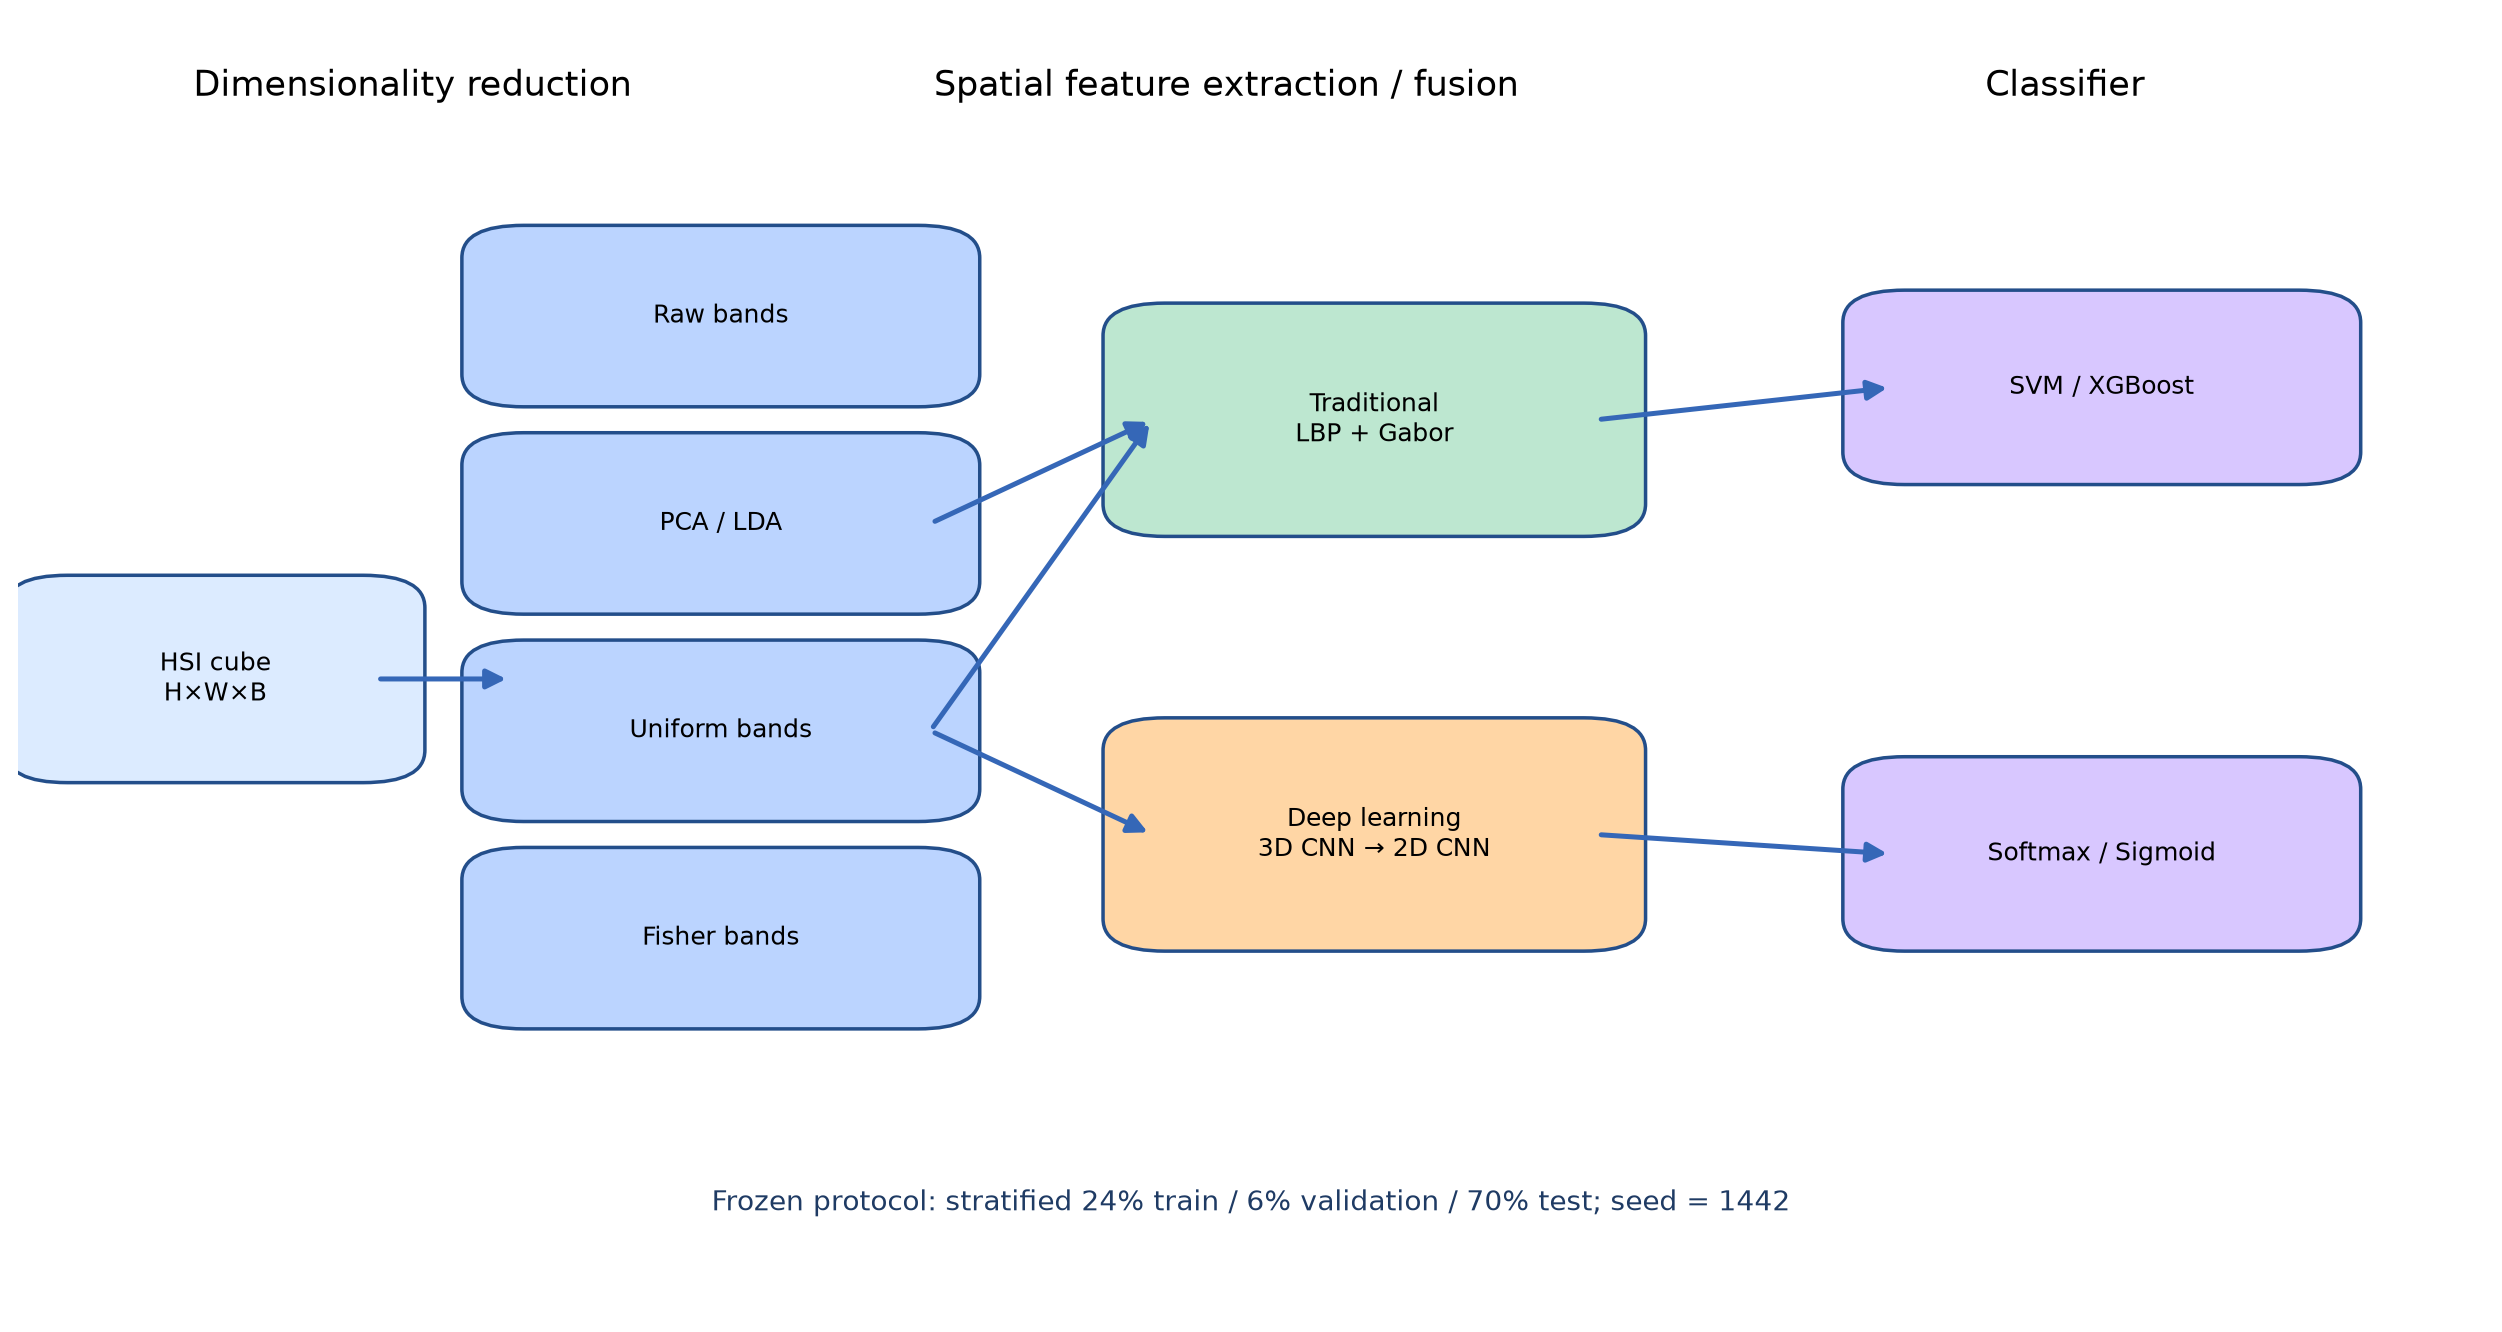

In [11]:
REPORT_FIGURES = PROJECT_ROOT / "coursework/outputs/report_figures"
combined = pd.read_csv(REPORT_FIGURES / "all_method_comparison.csv")
display(combined)
display(Image(filename=str(REPORT_FIGURES / "all_method_accuracy_comparison.png"), width=1100))
display(Image(filename=str(REPORT_FIGURES / "accuracy_efficiency_tradeoff.png"), width=900))
display(Image(filename=str(REPORT_FIGURES / "research_architecture.png"), width=1100))


## 5. 结果分析与建设性改进

1. 单独光谱分类不足：PCA15+SVM OA 为 93.70%，增加 LBP 或 Gabor 后分别达到 99.51% 和 99.57%，说明局部空间纹理是主要增益来源。
2. 传统融合很强：PCA15+LBP+Gabor+SVM 达 99.9365%，与 HybridSN 同量级，但 RBF-SVM 测试推理约 55.74 秒，显著慢于 HybridSN 约 7 秒，也远慢于 XGBoost 的亚秒级推理。
3. XGBoost 是效率方案：融合 XGBoost OA 99.2052%，精度低于融合 SVM，却提供约 7 万样本/秒吞吐。
4. 降维不是越“监督”越好：在仅使用中心光谱的统一 SVM 下，原始全波段 94.06%、PCA15 93.70%、LDA8 91.34%、均匀15波段 90.36%、Fisher15 70.59%。Fisher 单波段排序忽略波段间冗余与互补，是明显失败路线；后续应改为 mRMR、互信息、SPA 或可学习注意力选带。
5. 下一轮优化应优先验证泛化而非继续挤压随机划分 OA：空间块划分、多 seed 重复、跨数据集迁移；随后再做轻量化 HybridSN、BatchNorm/残差、光谱—空间注意力和数据增强。
